Map saved successfully with PyGMT data and Cartopy styling!


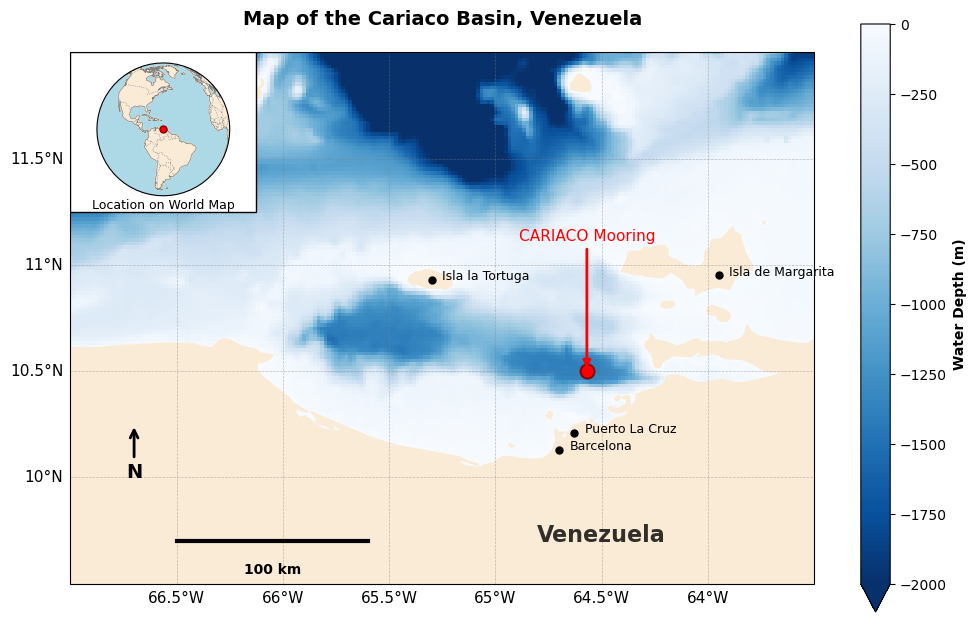

In [2]:
#!/usr/bin/env python3
"""
Create study site map for the Cariaco Basin using Cartopy for plotting
and PyGMT for high-resolution bathymetry data.
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors # Added for colormap normalization
import numpy as np
import pygmt # Added to load data

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# --- Main Map (Map 1) Setup ---

# Map boundaries
lon_min, lon_max = -67.0, -63.5
lat_min, lat_max = 9.5, 12.0
region = [lon_min, lon_max, lat_min, lat_max] # For pygmt

# CARIACO mooring location
mooring_lon = -64.57
mooring_lat = 10.5

# --- PyGMT Data Loading ---
# Load high-resolution bathymetry
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region)
# Clip grid to set land elevations to 0
grid = pygmt.grdclip(grid, above=[0, 0])
# --- End of PyGMT data ---

# --- Fixed Colormap ---
# Create a colormap (use 'ocean_r' to go from dark blue to light)
cmap = plt.get_cmap("Blues_r")
# Create a normalizer to clip the scale from -2000 (dark) to 0 (light)
norm = mcolors.Normalize(vmin=-2000, vmax=0)

# Create figure (Cartopy)
fig = plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# --- Plot PyGMT Grid using Cartopy/Xarray ---
grid.plot.pcolormesh(
    ax=ax,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    zorder=0,
    add_colorbar=False
)

# --- Cartopy Styling (from your preferred script) ---

# Add land feature
ax.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
# Add coastlines
#ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='darkblue', zorder=2)

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                  alpha=0.5, linestyle='--', zorder=3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Add cities
cities = {
    'Puerto La Cruz': (-64.63, 10.21),
    'Barcelona': (-64.70, 10.13)
}
for city, (clon, clat) in cities.items():
    ax.plot(clon, clat, 'o', color='black', markersize=5,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(clon + 0.05, clat, city, fontsize=9, color='black',
            transform=ccrs.PlateCarree(), zorder=5)

# Add islands
islands = {
    'Isla de Margarita': (-63.95, 10.95),
    'Isla la Tortuga': (-65.30, 10.93)
}
for island, (ilon, ilat) in islands.items():
    ax.plot(ilon, ilat, 'o', color='black', markersize=5,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(ilon + 0.05, ilat, island, fontsize=9, color='black',
            transform=ccrs.PlateCarree(), zorder=5)

# Add Venezuela label
ax.text(-64.5, 9.7, 'Venezuela', fontsize=16, color='black',
        weight='bold', ha='center', alpha=0.8,
        transform=ccrs.PlateCarree(), zorder=5)

# Add CARIACO mooring
ax.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=10,
        markeredgecolor='darkred', markeredgewidth=1.5,
        transform=ccrs.PlateCarree(), zorder=10)
ax.annotate('CARIACO Mooring',
            xy=(mooring_lon, mooring_lat),
            xytext=(mooring_lon, mooring_lat + 0.6),
            fontsize=11, color='red',
            ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-|>', color='red', lw=2, relpos=(0.5, 0.)),
            transform=ccrs.PlateCarree(), zorder=10)

# Add scale bar
scale_lon = -66.5
scale_lat = 9.7
scale_length = 0.9  # degrees ≈ 100 km
ax.plot([scale_lon, scale_lon + scale_length], [scale_lat, scale_lat],
        'k-', linewidth=3, transform=ccrs.PlateCarree(), zorder=10)
ax.text(scale_lon + scale_length/2, scale_lat - 0.15, '100 km',
        ha='center', fontsize=10, weight='bold',
        transform=ccrs.PlateCarree(), zorder=10)

# Add north arrow
arrow_lon = -66.7
arrow_lat = 10.0
ax.annotate('N', xy=(arrow_lon, arrow_lat + 0.25),
            xytext=(arrow_lon, arrow_lat),
            ha='center', fontsize=14, weight='bold',
            arrowprops=dict(arrowstyle='->', lw=2, color='black'),
            transform=ccrs.PlateCarree(), zorder=10)

# Title
ax.set_title('Map of the Cariaco Basin, Venezuela',
             fontsize=14, weight='bold', pad=20)

# --- Inset Map (Map 2) ---

# Define inset position and size
inset_x = 0.0
inset_y = 1.0 - 0.30
inset_w = 0.25
inset_h_total = 0.30

# Add white background patch
rect_patch = mpatches.Rectangle((inset_x, inset_y), inset_w, inset_h_total,
                                facecolor='white',
                                edgecolor='black',
                                linewidth=1.0,
                                transform=ax.transAxes,
                                zorder=11)
ax.add_patch(rect_patch)

# Define map height and position
map_h = inset_w
map_y = inset_y + (inset_h_total - map_h) - 0.02

# Create inset axes
ax_inset = ax.inset_axes([inset_x, map_y, inset_w, map_h],
                        projection=ccrs.Orthographic(
                            central_longitude=mooring_lon,
                            central_latitude=mooring_lat),
                        zorder=12)

# Plot world map features on inset axes
ax_inset.set_global()
ax_inset.add_feature(cfeature.OCEAN, color='lightblue', zorder=0)
ax_inset.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='grey', zorder=2)
ax_inset.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='grey',
                     linestyle=':', zorder=2)

# Add point for Cariaco location on inset
ax_inset.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=5,
              markeredgecolor='darkred', markeredgewidth=1.0,
              transform=ccrs.PlateCarree(), zorder=13)

# --- Fixed Label Position ---
# Add text label (lowered to 0.01 from 0.015)
text_x = inset_x + inset_w / 2
text_y = inset_y + 0.0 # Lowered this value
ax.text(text_x, text_y, "Location on World Map",
        ha='center', va='bottom', fontsize=9,
        transform=ax.transAxes, zorder=13)

# --- Add Colorbar for Bathymetry ---

# ---!!! FIXED ERROR HERE !!!---
# Corrected 'ScalarMapple' to 'ScalarMappable'
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# Add 'extend' to show that colors continue below -2000m
cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                    shrink=0.7, pad=0.05, extend='min') 
cbar.set_label('Water Depth (m)', fontsize=10, weight='bold')

# --- Final Save ---

# Adjust layout to prevent main title overlap
plt.subplots_adjust(top=0.95) 

plt.savefig('cariaco_basin_map_combined.png', dpi=300, bbox_inches='tight')
plt.savefig('cariaco_basin_map_combined.pdf', dpi=300, bbox_inches='tight')

print("Map saved successfully with PyGMT data and Cartopy styling!")